# I.4 — Random Walks & Brownian Motion

Flip a coin: heads step right ($+1$), tails step left ($-1$). Keep the running total:

$$x_n = x_{n-1} + \text{step}_n$$

— a recurrence again (hello, Interlude I.1), except now the rule has **dice in it**.
Out of pure noise, tonight: pollen dancing in water, stock charts, perfume crossing a room,
and the mathematical ancestor of diffusion models.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)   # a seeded random generator: same "random" numbers every run

In [2]:
# 20 coin flips. rng.choice picks randomly from the list, size=20 times.
flips = rng.choice([-1, 1], size=20)
print("steps:    ", flips)

# np.cumsum = CUMULATIVE sum: a Sigma that keeps every subtotal along the way.
print("position: ", np.cumsum(flips))

steps:     [-1  1  1 -1 -1  1 -1  1 -1 -1  1  1  1  1  1  1  1 -1  1 -1]
position:  [-1  0  1  0 -1  0 -1  0 -1 -2 -1  0  1  2  3  4  5  4  5  4]


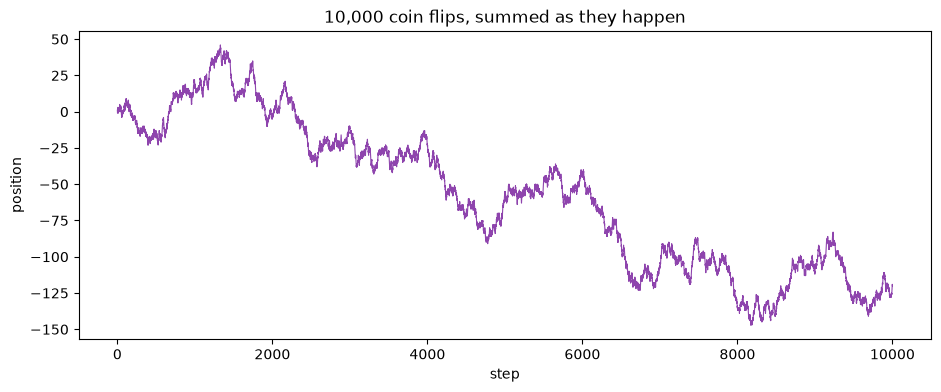

In [3]:
# Same idea, 10,000 flips. This jagged wanderer is a random walk.
walk = np.cumsum(rng.choice([-1, 1], size=10_000))

plt.figure(figsize=(11, 4))
plt.plot(walk, linewidth=0.8, color="#8e44ad")
plt.xlabel("step")
plt.ylabel("position")
plt.title("10,000 coin flips, summed as they happen")
plt.show()

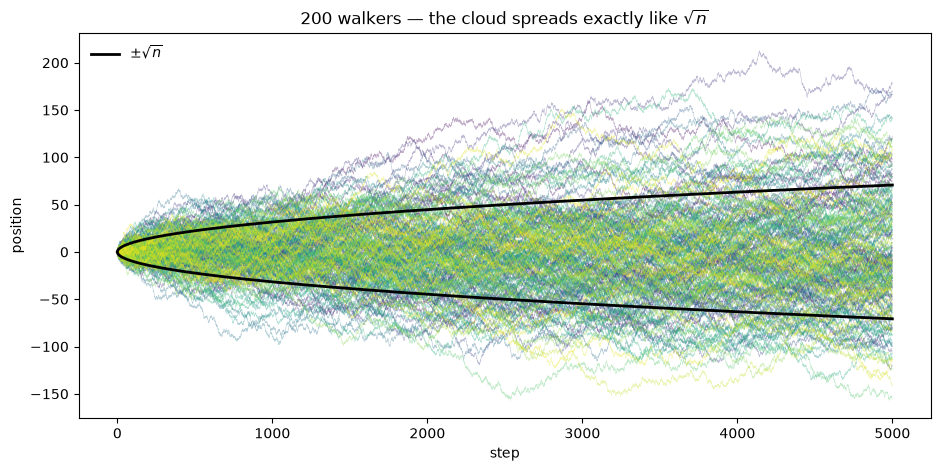

In [4]:
# Release 200 walkers at once: a 200 x 5000 grid of flips, cumsum along each row.
steps = rng.choice([-1, 1], size=(200, 5_000))
walks = np.cumsum(steps, axis=1)              # axis=1: sum along each walker's own row

n = np.arange(1, 5_001)
plt.figure(figsize=(11, 5))
for w, colour in zip(walks, plt.cm.viridis(np.linspace(0, 1, 200))):
    plt.plot(w, color=colour, linewidth=0.4, alpha=0.35)
plt.plot(n,  np.sqrt(n), color="black", linewidth=2, label=r"$\pm\sqrt{n}$")
plt.plot(n, -np.sqrt(n), color="black", linewidth=2)
plt.legend(frameon=False)
plt.xlabel("step")
plt.ylabel("position")
plt.title("200 walkers — the cloud spreads exactly like $\\sqrt{n}$")
plt.show()

No walker is predictable, but the *cloud* is: after $n$ steps the typical distance from home
is $\sqrt{n}$ — not $n$ (most steps cancel), not $0$ (they never cancel perfectly). To wander
twice as far takes **four** times as long. That $\sqrt{n}$ law governs how heat spreads, how
smells travel, and how much training noise moves a model's weights.

Now give the coin two dimensions — one flip for east–west, one for north–south — and let the
path draw itself. This is **Brownian motion**, the jitter Einstein used in 1905 to prove
atoms were real.

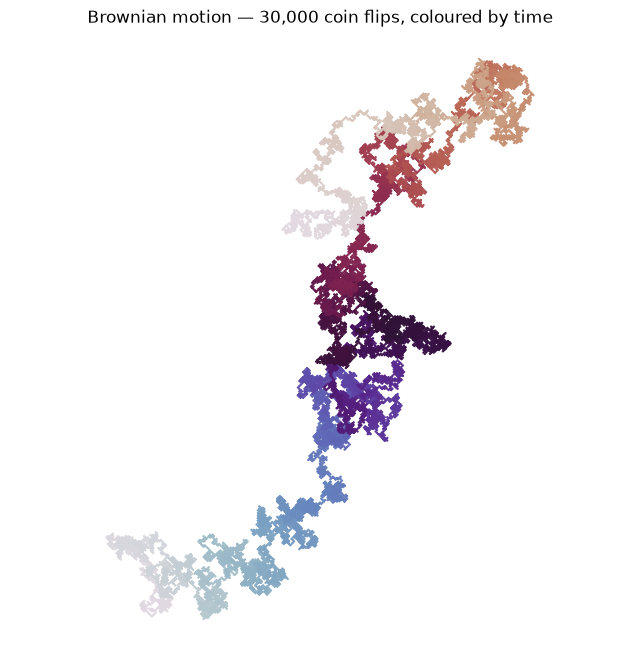

In [5]:
# A 30,000-step walk in 2D: each row of `steps` is (dx, dy); cumsum down the rows (axis=0).
xy = np.cumsum(rng.choice([-1, 1], size=(30_000, 2)), axis=0)

plt.figure(figsize=(8, 8))
plt.scatter(xy[:, 0], xy[:, 1], c=np.arange(len(xy)), cmap="twilight", s=0.5)  # coloured by time
plt.axis("equal")
plt.axis("off")
plt.title("Brownian motion — 30,000 coin flips, coloured by time")
plt.show()

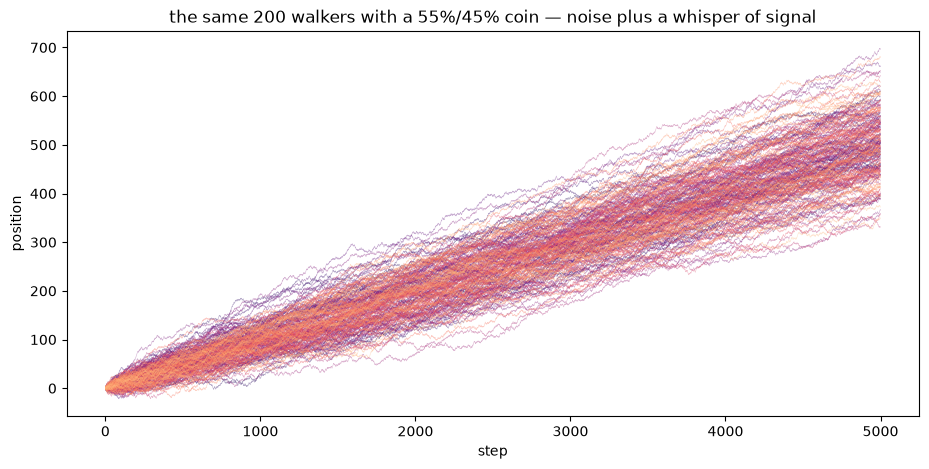

In [6]:
# YOUR TURN — load the dice.
#   1) Bias the coin: p=[0.45, 0.55] makes +1 slightly more likely. Re-run: the whole cloud DRIFTS.
#   2) Try p=[0.5, 0.5] vs p=[0.48, 0.52] — how little bias does it take to beat the noise?
#   3) Change the number of walkers or steps.
p_tails, p_heads = 0.45, 0.55

steps = rng.choice([-1, 1], size=(200, 5_000), p=[p_tails, p_heads])
walks = np.cumsum(steps, axis=1)

plt.figure(figsize=(11, 5))
for w, colour in zip(walks, plt.cm.magma(np.linspace(0.15, 0.85, 200))):
    plt.plot(w, color=colour, linewidth=0.4, alpha=0.35)
plt.xlabel("step")
plt.ylabel("position")
plt.title(f"the same 200 walkers with a {p_heads:.0%}/{p_tails:.0%} coin — noise plus a whisper of signal")
plt.show()

## What you just saw

That last experiment is the deepest thing tonight. An unbiased walk wanders; add the *tiniest*
bias and the cloud reliably drifts. Now rename the pieces: the noise is your random training
batches, and the bias is the **gradient** you computed in Module 3. Stochastic gradient descent
*is* a biased random walk — chaos plus a whisper of signal, drifting downhill to a trained model.

And diffusion models? They take an image and random-walk its pixels into pure noise, thousands
of tiny steps — then train a network to walk *backwards*. Every AI-generated image you've ever
seen is a random walk, reversed. Tonight's `np.cumsum` is the ancestor of all of it.

**The thread:** simple rules, iterated — even rules with dice in them — build nature's structure.
(Secretly drilled: randomness, cumulative sums, array axes. You didn't feel a thing.)

*Done? Tell Claude the smallest bias that still visibly beat the noise.*